# Customer Churn Prediction (Bank Customers)

# 1 Introduction and Problem Statement

Customer churn is one of the major challenges faced by banks and financial institutions. Customer churn occurs when customers stop using banking services or close their accounts. Losing customers can reduce company revenue and increase marketing costs because acquiring new customers is more expensive than retaining existing ones.

The objective of this project is to build a Machine Learning model that predicts whether a customer is likely to leave the bank. By identifying high-risk customers, banks can improve customer retention strategies and provide better services.

# 2 Dataset Understanding and Description

In [37]:
# Import Libraries 
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Machine Learning Model
from sklearn.ensemble import RandomForestClassifier

# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    mean_absolute_error,
    mean_squared_error
)

In [38]:
# Load Dataset

df = pd.read_csv("Churn_Modelling.csv")




In [39]:
# View Dataset (First Look)
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [40]:
# Dataset Shape
df.shape

(10000, 14)

In [41]:
# Column Names
df.columns

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='str')

# 3 Data Cleaning and Preparation

In [42]:
# Check Dataset Information
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.1 MB


In [43]:
# Check Missing Values
df.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [44]:
#Remove useless text columns
df_clean = df.drop(['Surname'], axis=1)
df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1, inplace=True)

# 4 Encode Categorical Features

In [45]:
# Label Encoding for Gender
le = LabelEncoder()

df['Gender'] = le.fit_transform(df['Gender'])

In [46]:
# One-Hot Encoding for Geography
df = pd.get_dummies(df, columns=['Geography'], drop_first=True)

# 5 Exploratory Data Analysis (EDA)
EDA helps understand customer behavior and identify patterns related to churn.

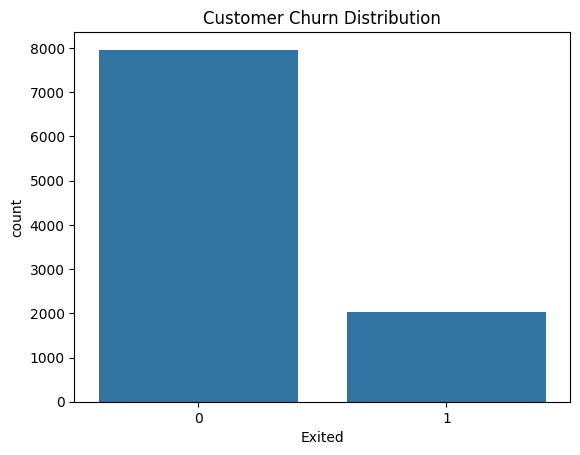

In [47]:
# Churn Distribution
sns.countplot(x='Exited', data=df)

plt.title("Customer Churn Distribution")
plt.show()

This graph shows the number of customers who stayed and who left the bank.

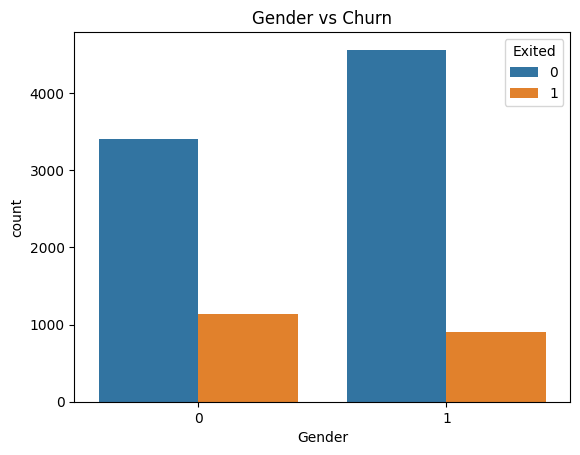

In [48]:
# Gender vs Churn
sns.countplot(x='Gender', hue='Exited', data=df)

plt.title("Gender vs Churn")
plt.show() 

This visualization helps compare churn behavior between male and female customers.

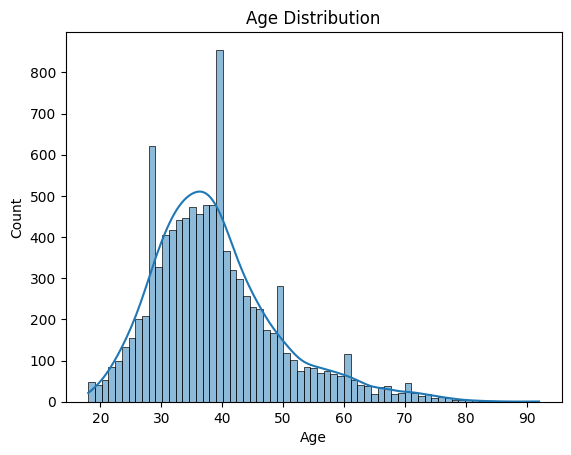

In [49]:
# Age Distribution
sns.histplot(df['Age'], kde=True)

plt.title("Age Distribution")
plt.show()

Shows the age range of customers in the dataset.

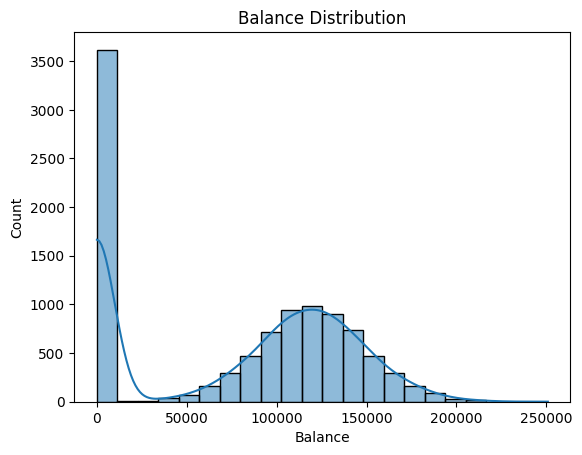

In [50]:
# Balance Distribution
sns.histplot(df['Balance'], kde=True)

plt.title("Balance Distribution")
plt.show() 

Displays how customer account balances are distributed.

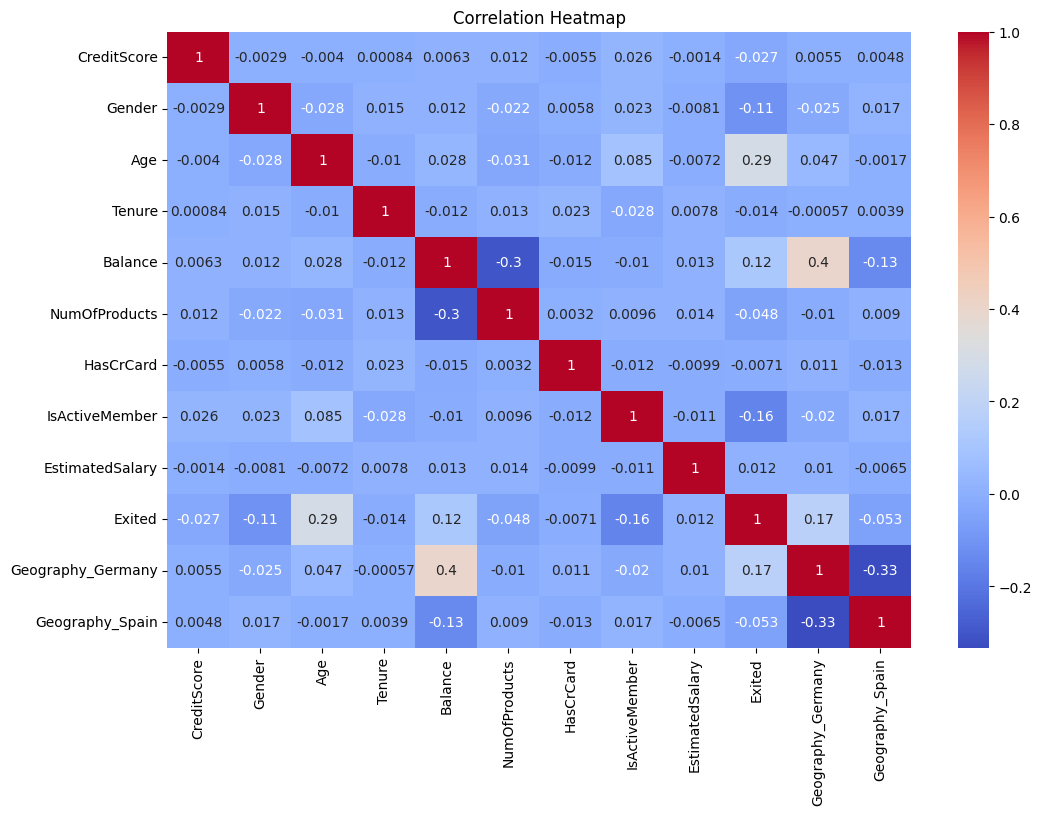

In [51]:
# Correlation Heatmap
plt.figure(figsize=(12,8))

sns.heatmap(df.corr(), annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap")
plt.show()

The heatmap shows relationships between features and customer churn.